In [1]:
import numpy as np

from mgwr.gwr import GWR as OfficialGWR
from mgwr.sel_bw import Sel_BW

from src.log.gwr_logger import GwrLogger
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset

Create the simulated dataset

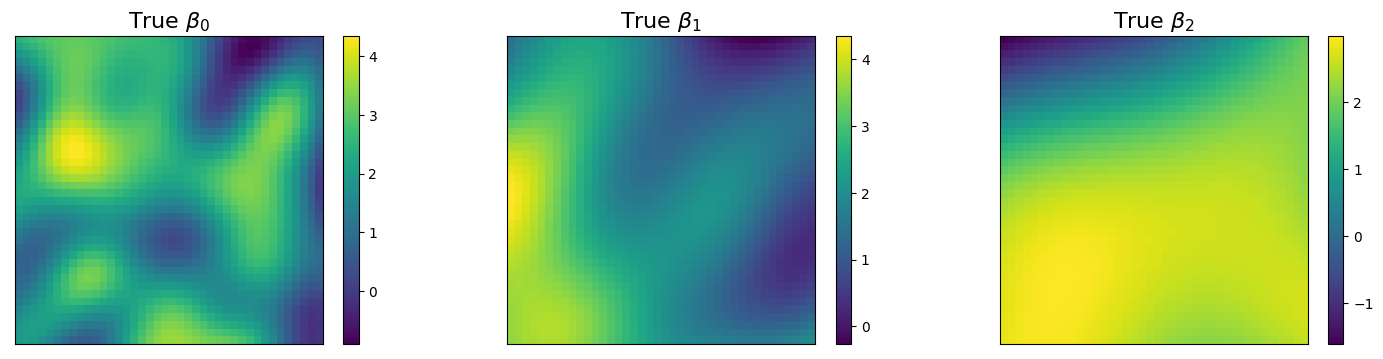

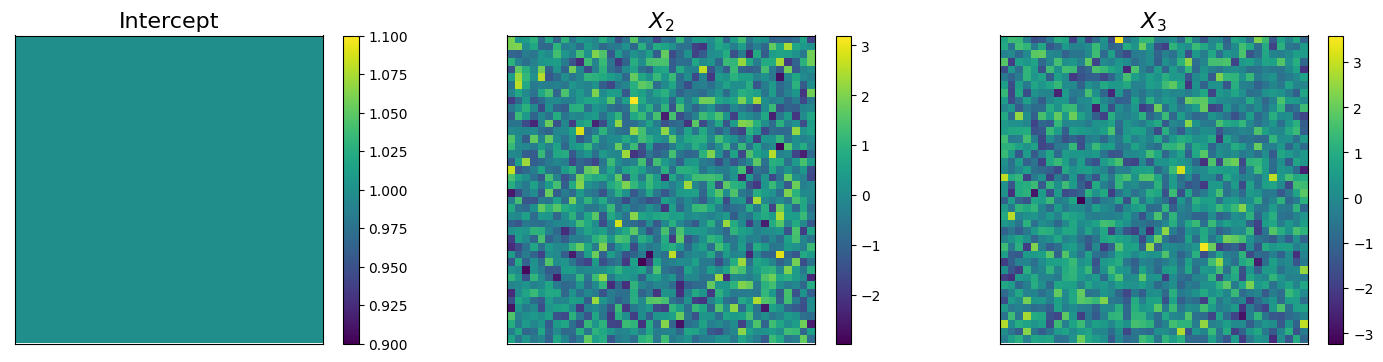

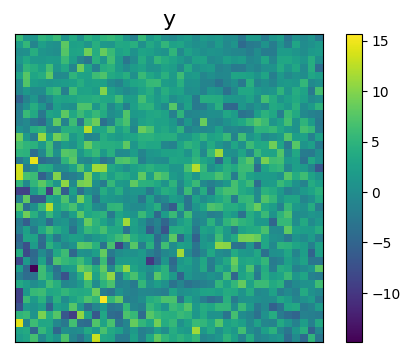

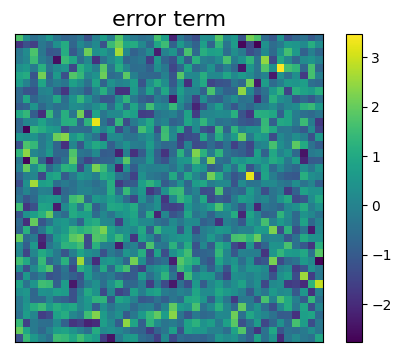

In [2]:
k = 2
field_size = 40
dataset = SimulatedSpatialDataset(
    k=k,
    field_size=field_size
)
[X] = dataset.generate_data()
[beta] = dataset.generate_processes()
[y, err] = dataset.fit_y(X, beta)

dataset.plot(
    b=beta.T,
    sub_title=[r"True $\beta_0$", r"True $\beta_1$", r"True $\beta_2$"],
    size=field_size
)

dataset.plot(
    b=X.T,
    sub_title=[r"Intercept", r"$X_2$", r"$X_3$"],
    size=field_size
)

dataset.plot(
    b=y.reshape(1, -1),
    sub_title=['y'],
    size=field_size
)

dataset.plot(
    b=err.reshape(1, -1),
    sub_title=['error term'],
    size=field_size
)


Create the GWR model (lmgwr codebase)

In [3]:
manual_bandwidth = 200

# Create a GWR kernel and GWR model.
kernel = GwrKernel(dataset, 'bisquare')
refactored_gwr = GWR(dataset, kernel)

Create the GWR model (Official MGWR codebase)

In [4]:
g_X = dataset.X[:, 1:]
g_y = dataset.y.reshape(-1, 1)
g_coords = dataset.coordinates.tolist()


# gwr_selector = Sel_BW(g_coords, g_y, g_X)
# gwr_bw = gwr_selector.search(bw_min=2)
# print(gwr_bw)
# official_gwr = OfficialGWR(g_coords, g_y, g_X, gwr_bw).fit()


official_gwr = OfficialGWR(g_coords, g_y, g_X, manual_bandwidth, hat_matrix=True)

Fit both models with the same bandwidth

In [5]:
refactored_gwr.update_bandwidth(manual_bandwidth).fit()
official_gwr_result = official_gwr.fit()

llf: -2410.341716460115
tr_S: 65.75401613941969
----------------------
first: 4820.68343292023
second: 139.41159180455696
----------------------
up: 213612.851646143
down: 1532.2459838605803
AICc: 4960.095024724787 



Compare outputs

In [6]:
s_matrix_match = np.allclose(refactored_gwr.S, official_gwr_result.S)
betas_match = np.allclose(refactored_gwr.betas, official_gwr_result.params)

print("="*60)
print("GWR Model Comparison")
print("="*60)
print(f"{'Metric':30} {'Custom GWR':>12} {'Official GWR':>15}")
print("-"*60)
print(f"{'R-squared':30} {refactored_gwr.r_squared:12.4f} {official_gwr_result.R2:15.4f}")
print(f"{'AIC':30} {refactored_gwr.aic:12.2f} {official_gwr_result.aic:15.2f}")
print(f"{'AICc':30} {refactored_gwr.aicc:12.2f} {official_gwr_result.aicc:15.2f}")
print("-"*60)
print(f"{'Coefficient matrices match?':30} {str(betas_match):>12}")
print(f"{'S matrices match?':30} {str(s_matrix_match):>12}")
print("="*60)


GWR Model Comparison
Metric                           Custom GWR    Official GWR
------------------------------------------------------------
R-squared                            0.9011          0.9011
AIC                                 4954.19         4954.19
AICc                                4960.10         4960.10
------------------------------------------------------------
Coefficient matrices match?            True
S matrices match?                      True


llf: -1943.082156231876
tr_S: 403.12295303104537
----------------------
first: 3886.164312463752
second: 1082.281606278897
----------------------
up: 1293193.4496993453
down: 1194.8770469689546
AICc: 4968.445918742649 

Processed  bw=30
llf: -2023.2500784829408
tr_S: 315.96134395556305
----------------------
first: 4046.5001569658816
second: 791.1433059181063
----------------------
up: 1014276.3006578018
down: 1282.038656044437
AICc: 4837.643462883988 

Processed  bw=40
llf: -2084.2428665733214
tr_S: 249.94330191565862
----------------------
first: 4168.485733146643
second: 595.6860473830505
----------------------
up: 803018.5661301076
down: 1348.0566980843414
AICc: 4764.171780529693 

Processed  bw=50
llf: -2110.523435686643
tr_S: 227.3892462001485
----------------------
first: 4221.046871373286
second: 533.2262174467076
----------------------
up: 730845.5878404753
down: 1370.6107537998514
AICc: 4754.273088819994 

Processed  bw=60
llf: -2164.8364184926822
tr_S: 175.98106876159022
---

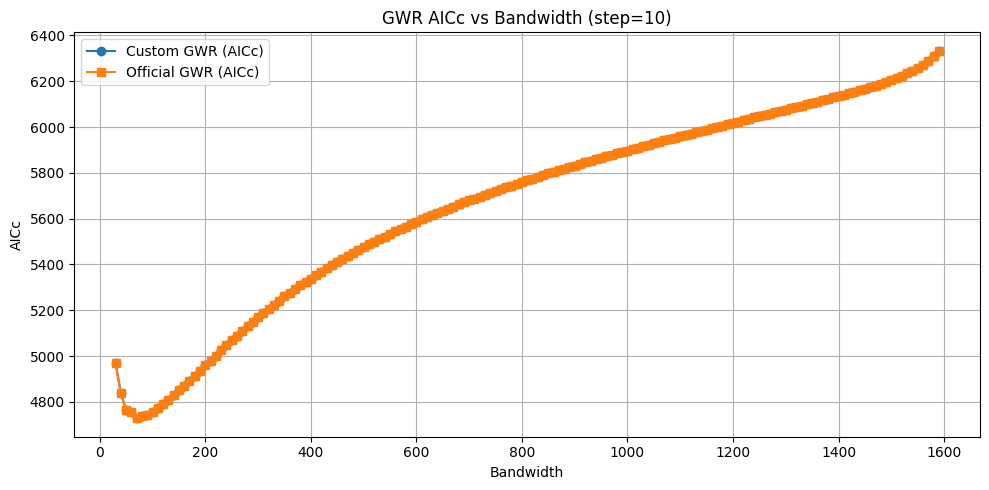

In [7]:
import matplotlib.pyplot as plt
import numpy as np

bw_list = []

aicc_custom = []
aicc_official = []

for bw in range(30 , 1600, 10):
    # custom/refactored
    refactored_gwr.update_bandwidth(bw).fit()
    aicc_custom.append(float(refactored_gwr.aicc))

    tmp = OfficialGWR(g_coords, g_y, g_X, bw, hat_matrix=True)
    res = tmp.fit()
    aicc_official.append(float(res.aicc))

    bw_list.append(bw)
    print(f"Processed  bw={bw}")

# plot
plt.figure(figsize=(10, 5))
plt.plot(bw_list, aicc_custom, marker='o', label='Custom GWR (AICc)')
plt.plot(bw_list, aicc_official, marker='s', label='Official GWR (AICc)')
plt.xlabel('Bandwidth')
plt.ylabel('AICc')
plt.title('GWR AICc vs Bandwidth (step=10)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [8]:
# find lowest AICc and corresponding bandwidth
best_idx = int(np.argmin(aicc_official))
best_aicc = float(aicc_official[best_idx])
best_bw = bw_list[best_idx]

print(f"Lowest AICc: {best_aicc:.6f}")
print(f"Bandwidth at lowest AICc: {best_bw} (index {best_idx})")


Lowest AICc: 4727.937169
Bandwidth at lowest AICc: 70 (index 4)


In [9]:

print(refactored_gwr.update_bandwidth(68).fit().aicc)
print(refactored_gwr.update_bandwidth(69).fit().aicc)
print(refactored_gwr.update_bandwidth(70).fit().aicc)
print(refactored_gwr.update_bandwidth(71).fit().aicc)
print(refactored_gwr.update_bandwidth(72).fit().aicc)

llf: -2139.58385356515
tr_S: 202.95845373226493
----------------------
first: 4279.1677071303
second: 467.8477524123776
----------------------
up: 652667.0519432478
down: 1395.0415462677352
AICc: 4747.0154595426775 

4747.0154595426775
llf: -2139.8484588713654
tr_S: 202.84254833908932
----------------------
first: 4279.696917742731
second: 467.5430388939532
----------------------
up: 652296.1546850859
down: 1395.1574516609107
AICc: 4747.239956636684 

4747.239956636684
llf: -2164.8364184926822
tr_S: 175.98106876159022
----------------------
first: 4329.6728369853645
second: 398.2643322082036
----------------------
up: 566339.4200370887
down: 1422.0189312384098
AICc: 4727.9371691935685 

4727.9371691935685
llf: -2167.181064998268
tr_S: 174.66341101703387
----------------------
first: 4334.362129996536
second: 394.9332291500838
----------------------
up: 562122.9152545084
down: 1423.336588982966
AICc: 4729.29535914662 

4729.29535914662
llf: -2169.287900810862
tr_S: 173.6637519562211
---

In [10]:
from src.model.lgwr import LGWR
from src.kernel.lgwr_kernel import LgwrKernel

kernel = LgwrKernel(dataset, 'bisquare')
lgwr = LGWR(dataset, kernel)
print(lgwr.update_local_bandwidth_vector(np.array([70 for i in range(0, 1600)])).fit().aicc)

llf: -2164.8364184926822
tr_S: 175.98106876159022
----------------------
first: 4329.6728369853645
second: 398.2643322082036
----------------------
up: 566339.4200370887
down: 1422.0189312384098
AICc: 4727.9371691935685 

4727.9371691935685
